In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# InsightRAG – Exploratory Data Analysis

## E-Commerce Business Intelligence & Analytics

This notebook performs Exploratory Data Analysis (EDA) on the InsightRAG e-commerce dataset.

### Objectives

- Understand the structure and quality of the processed dataset
- Analyze sales and profit performance
- Analyze customer purchasing behavior
- Identify product and category performance
- Analyze return patterns
- Analyze the impact of discounts on profitability
- Investigate intentionally created business scenarios
- Generate actionable business insights for the RAG system

In [11]:
import pandas as pd
import os

data_path = os.path.join(
    "..",
    "data",
    "processed",
    "master_analytics_dataset.csv"
)

print("Looking for:")
print(os.path.abspath(data_path))

df = pd.read_csv(data_path)

print("\nDataset loaded successfully!")
print(f"Dataset shape: {df.shape}")

Looking for:
C:\Users\karti\OneDrive\Desktop\InsightRAG\data\processed\master_analytics_dataset.csv

Dataset loaded successfully!
Dataset shape: (20118, 37)


In [9]:
import os

print(os.getcwd())

C:\Users\karti\OneDrive\Desktop\InsightRAG\notebooks


In [12]:
df.head()

,order_item_id,order_id,product_id,customer_id,customer_name,age,gender,city,state,customer_segment,...,discount_percentage,discount_category,sales_amount,total_cost,profit,profit_margin_percentage,is_returned,return_status,return_reason,return_date
0,OI0000001,O000001,P0203,C01741,Aradhana Tailor,65,Female,Ahmedabad,Gujarat,Budget,...,0,No Discount,33493.82,22074.92,11418.90,34.09,0,Not Returned,NaN,NaN
1,OI0000002,O000001,P0245,C01741,Aradhana Tailor,65,Female,Ahmedabad,Gujarat,Budget,...,0,No Discount,1235.38,769.49,465.89,37.71,0,Not Returned,NaN,NaN
2,OI0000003,O000001,P0068,C01741,Aradhana Tailor,65,Female,Ahmedabad,Gujarat,Budget,...,0,No Discount,9024.96,7043.56,1981.40,21.95,0,Not Returned,NaN,NaN
3,OI0000004,O000003,P0092,C00282,Timothy Bhatnagar,59,Male,Hyderabad,Telangana,Regular,...,5,Low Discount,13703.65,9054.55,4649.10,33.93,0,Not Returned,NaN,NaN
4,OI0000005,O000003,P0037,C00282,Timothy Bhatnagar,59,Male,Hyderabad,Telangana,Regular,...,5,Low Discount,203056.74,143008.23,60048.51,29.57,0,Not Returned,NaN,NaN


In [13]:
df.tail()

,order_item_id,order_id,product_id,customer_id,customer_name,age,gender,city,state,customer_segment,...,discount_percentage,discount_category,sales_amount,total_cost,profit,profit_margin_percentage,is_returned,return_status,return_reason,return_date
20113,OI0020114,O009999,P0205,C01345,Faras Nair,46,Female,Ahmedabad,Gujarat,Premium,...,10,Low Discount,18063.54,11212.00,6851.54,37.93,0,Not Returned,NaN,NaN
20114,OI0020115,O010000,P0091,C01724,Jalsa Rao,38,Male,Ahmedabad,Gujarat,Premium,...,0,No Discount,9884.40,7883.46,2000.94,20.24,0,Not Returned,NaN,NaN
20115,OI0020116,O010000,P0035,C01724,Jalsa Rao,38,Male,Ahmedabad,Gujarat,Premium,...,5,Low Discount,1768.88,1176.70,592.18,33.48,0,Not Returned,NaN,NaN
20116,OI0020117,O010000,P0052,C01724,Jalsa Rao,38,Male,Ahmedabad,Gujarat,Premium,...,0,No Discount,32765.44,18718.50,14046.94,42.87,0,Not Returned,NaN,NaN
20117,OI0020118,O010000,P0072,C01724,Jalsa Rao,38,Male,Ahmedabad,Gujarat,Premium,...,10,Low Discount,23429.97,19538.36,3891.61,16.61,0,Not Returned,NaN,NaN


In [14]:
df.sample(5, random_state=42)

,order_item_id,order_id,product_id,customer_id,customer_name,age,gender,city,state,customer_segment,...,discount_percentage,discount_category,sales_amount,total_cost,profit,profit_margin_percentage,is_returned,return_status,return_reason,return_date
451,OI0000452,O000218,P0002,C01093,Ekavir Kari,23,Male,Delhi,Delhi,Premium,...,0,No Discount,7860.72,5478.25,2382.47,30.31,0,Not Returned,NaN,NaN
17161,OI0017162,O008522,P0095,C01954,Nitara Chandra,56,Female,Jaipur,Rajasthan,Premium,...,0,No Discount,39146.28,27593.88,11552.40,29.51,0,Not Returned,NaN,NaN
4269,OI0004270,O002067,P0212,C01179,Hamsini Ben,35,Female,Lucknow,Uttar Pradesh,Budget,...,0,No Discount,12699.70,7292.39,5407.31,42.58,0,Not Returned,NaN,NaN
16583,OI0016584,O008245,P0121,C01085,Caleb Minhas,70,Female,Jaipur,Rajasthan,Regular,...,20,Medium Discount,6910.32,5437.46,1472.86,21.31,0,Not Returned,NaN,NaN
16325,OI0016326,O008115,P0118,C01631,Gaurav Mander,55,Male,Bengaluru,Karnataka,Budget,...,5,Low Discount,5981.22,4529.12,1452.10,24.28,0,Not Returned,NaN,NaN


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20118 entries, 0 to 20117
Data columns (total 37 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_item_id             20118 non-null  str    
 1   order_id                  20118 non-null  str    
 2   product_id                20118 non-null  str    
 3   customer_id               20118 non-null  str    
 4   customer_name             20118 non-null  str    
 5   age                       20118 non-null  int64  
 6   gender                    20118 non-null  str    
 7   city                      20118 non-null  str    
 8   state                     20118 non-null  str    
 9   customer_segment          20118 non-null  str    
 10  signup_date               20118 non-null  str    
 11  product_name              20118 non-null  str    
 12  category                  20118 non-null  str    
 13  sub_category              20118 non-null  str    
 14  supplier         

In [16]:
print("TOTAL COLUMNS:", len(df.columns))

print("\nCOLUMN NAMES:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

TOTAL COLUMNS: 37

COLUMN NAMES:
1. order_item_id
2. order_id
3. product_id
4. customer_id
5. customer_name
6. age
7. gender
8. city
9. state
10. customer_segment
11. signup_date
12. product_name
13. category
14. sub_category
15. supplier
16. cost_price
17. selling_price
18. order_date
19. order_year
20. order_month
21. order_month_name
22. order_quarter
23. year_month
24. year_quarter
25. payment_method
26. order_status
27. quantity
28. discount_percentage
29. discount_category
30. sales_amount
31. total_cost
32. profit
33. profit_margin_percentage
34. is_returned
35. return_status
36. return_reason
37. return_date


In [17]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

if len(missing_values) == 0:
    print("No missing values found in the master dataset.")
else:
    print("Missing Values:")
    print(missing_values.sort_values(ascending=False))

Missing Values:
return_reason    18397
return_date      18397
dtype: int64


In [18]:
duplicate_rows = df.duplicated().sum()

print(f"Total duplicate rows: {duplicate_rows}")

Total duplicate rows: 0


In [19]:
df.describe()

,age,cost_price,selling_price,order_year,order_month,quantity,discount_percentage,sales_amount,total_cost,profit,profit_margin_percentage,is_returned
count,20118.000000,20118.000000,20118.000000,20118.000000,20118.000000,20118.000000,20118.000000,20118.000000,20118.000000,20118.000000,20118.000000,20118.000000
mean,43.833085,9984.494195,14827.664269,2024.496868,6.566955,3.018938,8.362163,40965.282446,30461.522512,10503.759934,25.410154,0.085545
std,15.348617,13156.211561,19527.465812,0.500003,3.429455,1.411289,7.710794,62964.445720,47027.906330,18724.841694,10.959618,0.279698
min,18.000000,287.780000,483.110000,2024.000000,1.000000,1.000000,0.000000,362.330000,287.780000,-73008.110000,-36.750000,0.000000
25%,30.000000,2145.610000,3037.710000,2024.000000,4.000000,2.000000,0.000000,6789.590000,4913.730000,1398.122500,18.880000,0.000000
50%,44.000000,3818.100000,5549.110000,2024.000000,7.000000,3.000000,5.000000,15455.200000,11327.850000,3611.745000,25.800000,0.000000
75%,57.000000,11012.770000,16715.780000,2025.000000,10.000000,4.000000,15.000000,46975.540000,34377.562500,10792.400000,34.090000,0.000000
max,70.000000,60354.350000,79615.860000,2025.000000,12.000000,5.000000,40.000000,398079.300000,337984.360000,166841.650000,44.950000,1.000000


In [20]:
categorical_columns = [
    "gender",
    "city",
    "state",
    "customer_segment",
    "category",
    "sub_category",
    "supplier",
    "payment_method",
    "order_status",
    "return_reason"
]

for column in categorical_columns:
    if column in df.columns:
        print("\n" + "=" * 60)
        print(column.upper())
        print("=" * 60)
        print(df[column].value_counts())


GENDER
gender
Female    10126
Male       9992
Name: count, dtype: int64

CITY
city
Ahmedabad    2273
Jaipur       2171
Pune         2133
Chennai      2130
Lucknow      2077
Kolkata      1991
Mumbai       1981
Bengaluru    1951
Hyderabad    1876
Delhi        1535
Name: count, dtype: int64

STATE
state
Maharashtra      4114
Gujarat          2273
Rajasthan        2171
Tamil Nadu       2130
Uttar Pradesh    2077
West Bengal      1991
Karnataka        1951
Telangana        1876
Delhi            1535
Name: count, dtype: int64

CUSTOMER_SEGMENT
customer_segment
Regular    11093
Budget      5096
Premium     3929
Name: count, dtype: int64

CATEGORY
category
Home & Kitchen    4324
Sports            4276
Clothing          4067
Electronics       3935
Beauty            3516
Name: count, dtype: int64

SUB_CATEGORY
sub_category
Fitness Equipment     2350
Outdoor Equipment     1926
Kitchen Appliances    1677
Home Decor            1485
Haircare              1481
Headphones            1352
T-Shirts    

In [21]:
# ============================================
# SALES AND PROFIT OVERVIEW
# ============================================

total_sales = df["sales_amount"].sum()
total_profit = df["profit"].sum()
total_cost = df["total_cost"].sum()
total_quantity = df["quantity"].sum()

profit_margin = (total_profit / total_sales) * 100

print("=" * 60)
print("OVERALL BUSINESS PERFORMANCE")
print("=" * 60)

print(f"\nTotal Sales: ₹{total_sales:,.2f}")
print(f"Total Cost: ₹{total_cost:,.2f}")
print(f"Total Profit: ₹{total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Overall Profit Margin: {profit_margin:.2f}%")

OVERALL BUSINESS PERFORMANCE

Total Sales: ₹824,139,552.25
Total Cost: ₹612,824,909.90
Total Profit: ₹211,314,642.35
Total Quantity Sold: 60,735
Overall Profit Margin: 25.64%


In [22]:
# ============================================
# CATEGORY-WISE SALES AND PROFIT ANALYSIS
# ============================================

category_performance = (
    df.groupby("category")
    .agg(
        total_sales=("sales_amount", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum")
    )
    .sort_values("total_sales", ascending=False)
)

category_performance["profit_margin_%"] = (
    category_performance["total_profit"]
    / category_performance["total_sales"]
    * 100
).round(2)

category_performance

,total_sales,total_profit,total_quantity,profit_margin_%
category,,,,
Electronics,4.969885e+08,1.264938e+08,11899,25.45
Home & Kitchen,1.664155e+08,4.323874e+07,13004,25.98
Sports,9.615111e+07,2.562841e+07,12870,26.65
Clothing,3.903951e+07,9.747983e+06,12302,24.97
Beauty,2.554493e+07,6.205709e+06,10660,24.29


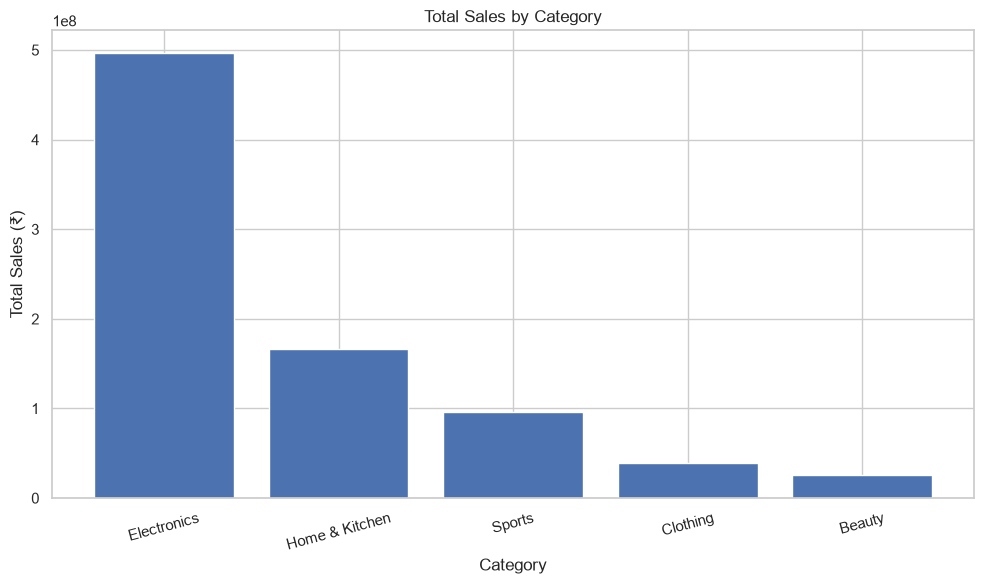

In [23]:
import matplotlib.pyplot as plt

# ============================================
# CATEGORY-WISE SALES AND PROFIT VISUALIZATION
# ============================================

# Sales by Category
plt.figure(figsize=(10, 6))

plt.bar(
    category_performance.index,
    category_performance["total_sales"]
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales (₹)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

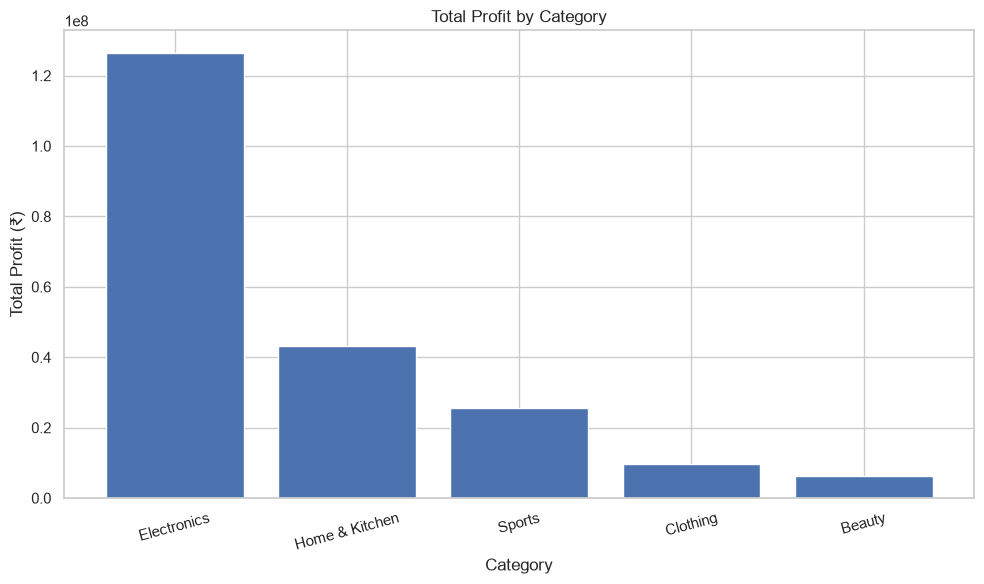

In [24]:
# ============================================
# PROFIT BY CATEGORY
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    category_performance.index,
    category_performance["total_profit"]
)

plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit (₹)")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [25]:
# ============================================
# MONTHLY SALES AND PROFIT TREND
# ============================================

# Create a copy so we don't modify the original dataset
monthly_df = df.copy()

# Make sure order_date is datetime
monthly_df["order_date"] = pd.to_datetime(monthly_df["order_date"])

# Create a Year-Month column
monthly_df["year_month"] = monthly_df["order_date"].dt.to_period("M")

# Calculate monthly sales and profit
monthly_performance = (
    monthly_df.groupby("year_month")
    .agg(
        total_sales=("sales_amount", "sum"),
        total_profit=("profit", "sum")
    )
)

monthly_performance

,total_sales,total_profit
year_month,,
2024-01,35066586.65,9587821.98
2024-02,27878150.07,7543529.23
2024-03,37177337.89,10122199.87
2024-04,35839578.11,9875972.81
2024-05,35600254.75,9671022.75
2024-06,33185273.12,9042214.96
2024-07,34596514.82,9714014.50
2024-08,37569778.67,10157962.03
2024-09,36152210.70,9396542.44


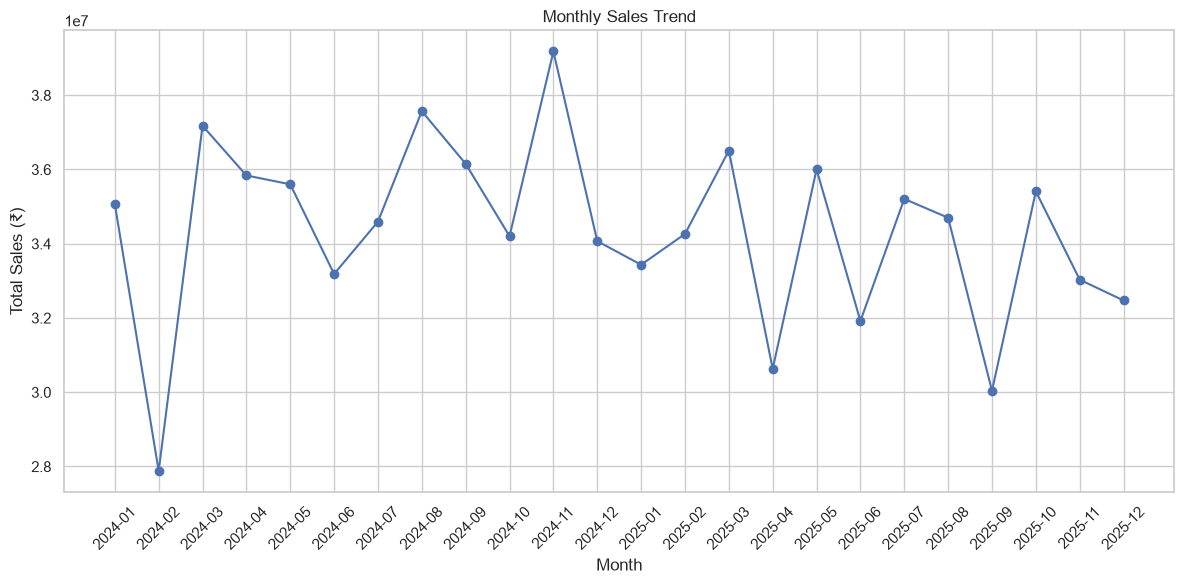

In [26]:
# ============================================
# MONTHLY SALES TREND
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance.index.astype(str),
    monthly_performance["total_sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

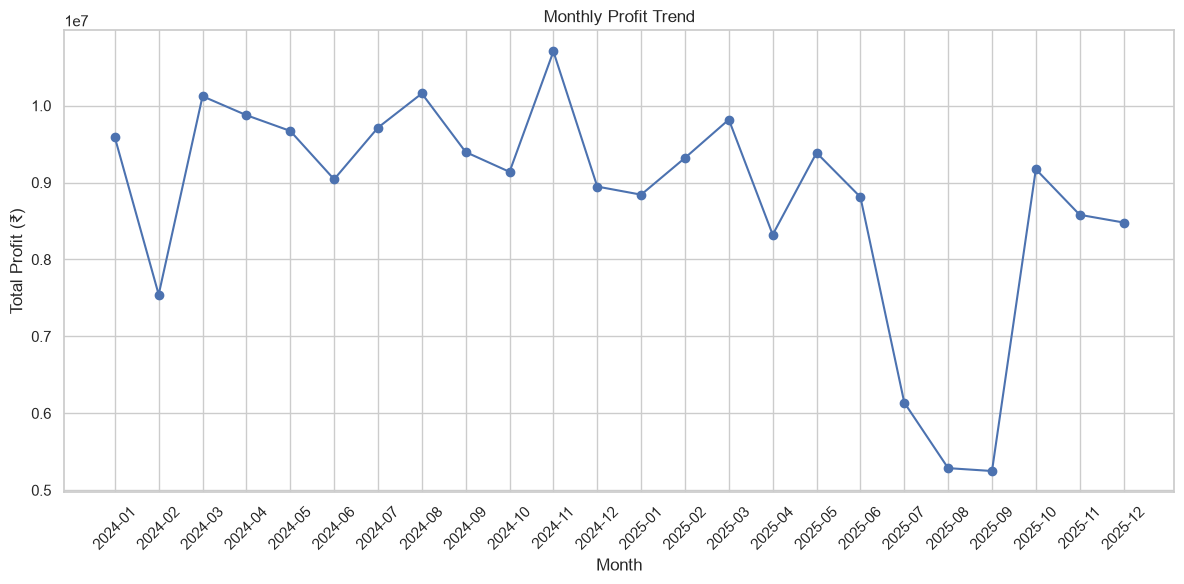

In [27]:
# ============================================
# MONTHLY PROFIT TREND
# ============================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_performance.index.astype(str),
    monthly_performance["total_profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [28]:
# ============================================
# ELECTRONICS QUARTERLY PERFORMANCE ANALYSIS
# ============================================

electronics_df = df[df["category"] == "Electronics"].copy()

# Ensure order_date is datetime
electronics_df["order_date"] = pd.to_datetime(electronics_df["order_date"])

# Create quarter column
electronics_df["quarter"] = electronics_df["order_date"].dt.to_period("Q")

# Calculate quarterly performance
electronics_quarterly = (
    electronics_df.groupby("quarter")
    .agg(
        total_sales=("sales_amount", "sum"),
        total_cost=("total_cost", "sum"),
        total_profit=("profit", "sum")
    )
)

# Calculate profit margin
electronics_quarterly["profit_margin_%"] = (
    electronics_quarterly["total_profit"]
    / electronics_quarterly["total_sales"]
    * 100
).round(2)

electronics_quarterly

,total_sales,total_cost,total_profit,profit_margin_%
quarter,,,,
2024Q1,59671210.79,42840593.64,16830617.15,28.21
2024Q2,63558048.71,45736485.95,17821562.76,28.04
2024Q3,68482472.98,49557211.36,18925261.62,27.64
2024Q4,65179413.08,47245370.33,17934042.75,27.51
2025Q1,63658271.88,46381209.94,17277061.94,27.14
2025Q2,56115304.66,40594586.22,15520718.44,27.66
2025Q3,58396436.58,52669906.50,5726530.08,9.81
2025Q4,61927331.38,45469321.77,16458009.61,26.58


## 5. Category Performance Analysis

In this section, we analyze how different product categories perform in terms of:

- Total Sales
- Total Profit
- Quantity Sold
- Profit Margin

In [29]:
category_performance = df.groupby("category").agg(
    total_sales=("sales_amount", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum")
).reset_index()

category_performance["profit_margin_%"] = (
    category_performance["total_profit"]
    / category_performance["total_sales"]
    * 100
).round(2)

category_performance = category_performance.sort_values(
    by="total_sales",
    ascending=False
)

category_performance

,category,total_sales,total_profit,total_quantity,profit_margin_%
2,Electronics,4.969885e+08,1.264938e+08,11899,25.45
3,Home & Kitchen,1.664155e+08,4.323874e+07,13004,25.98
4,Sports,9.615111e+07,2.562841e+07,12870,26.65
1,Clothing,3.903951e+07,9.747983e+06,12302,24.97
0,Beauty,2.554493e+07,6.205709e+06,10660,24.29


In [30]:
category_analysis = (
    df.groupby("category")
    .agg(
        total_sales=("sales_amount", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        average_discount=("discount_percentage", "mean")
    )
    .sort_values("total_sales", ascending=False)
)

category_analysis["profit_margin_%"] = (
    category_analysis["total_profit"]
    / category_analysis["total_sales"]
    * 100
).round(2)

category_analysis

,total_sales,total_profit,total_quantity,average_discount,profit_margin_%
category,,,,,
Electronics,4.969885e+08,1.264938e+08,11899,9.156290,25.45
Home & Kitchen,1.664155e+08,4.323874e+07,13004,7.883904,25.98
Sports,9.615111e+07,2.562841e+07,12870,7.794668,26.65
Clothing,3.903951e+07,9.747983e+06,12302,9.181215,24.97
Beauty,2.554493e+07,6.205709e+06,10660,7.804323,24.29


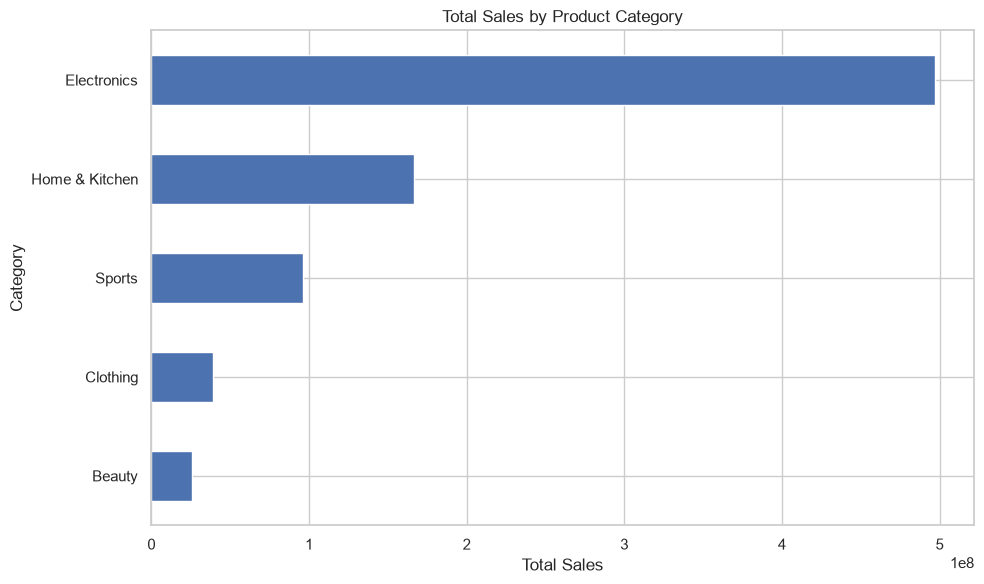

In [31]:
import matplotlib.pyplot as plt

category_analysis["total_sales"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

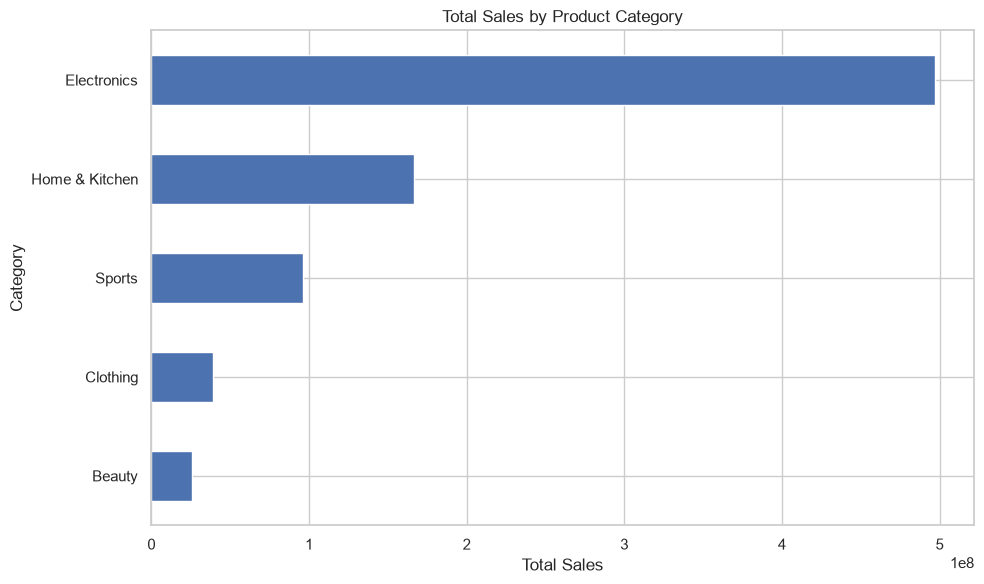

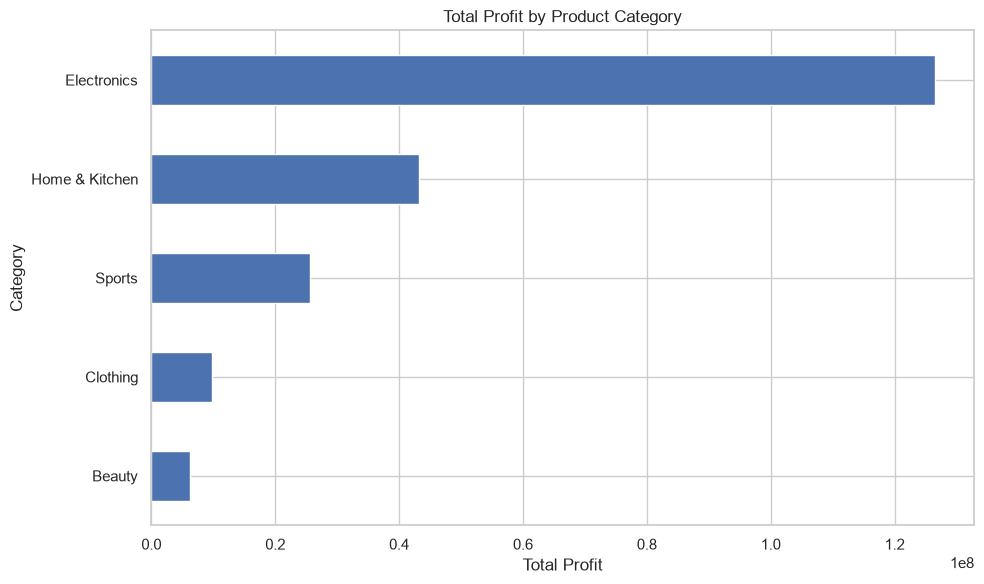

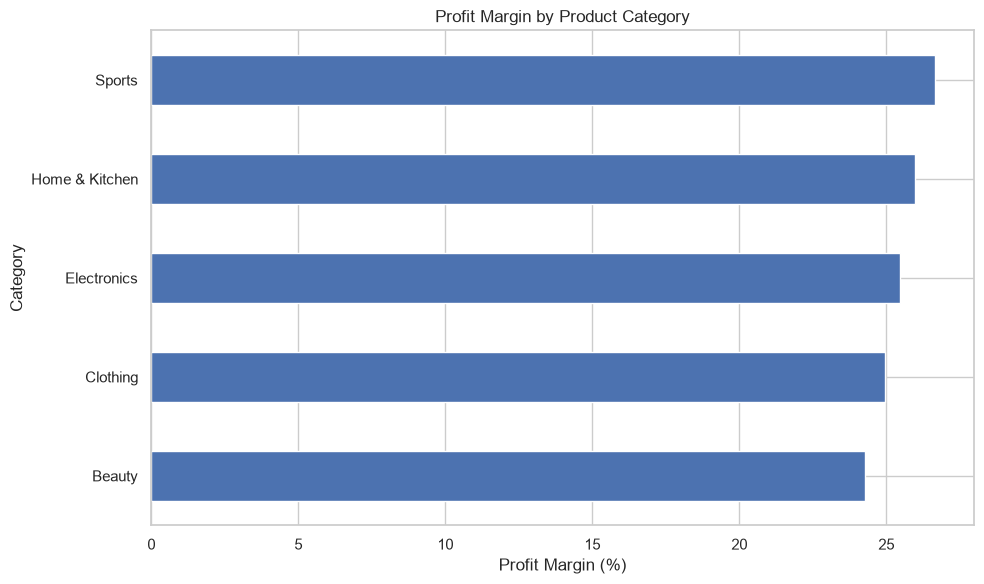

In [32]:
import matplotlib.pyplot as plt

# ---------------------------------------------------
# 1. TOTAL SALES BY CATEGORY
# ---------------------------------------------------

category_analysis["total_sales"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Total Sales by Product Category")
plt.xlabel("Total Sales")
plt.ylabel("Category")

plt.tight_layout()
plt.show()


# ---------------------------------------------------
# 2. TOTAL PROFIT BY CATEGORY
# ---------------------------------------------------

category_analysis["total_profit"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Total Profit by Product Category")
plt.xlabel("Total Profit")
plt.ylabel("Category")

plt.tight_layout()
plt.show()


# ---------------------------------------------------
# 3. PROFIT MARGIN BY CATEGORY
# ---------------------------------------------------

category_analysis["profit_margin_%"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Profit Margin by Product Category")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

In [33]:
# ---------------------------------------------------
# PRODUCT PERFORMANCE ANALYSIS
# ---------------------------------------------------

product_analysis = (
    df.groupby(["product_id", "product_name", "category"])
    .agg(
        total_sales=("sales_amount", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        average_discount=("discount_percentage", "mean")
    )
    .reset_index()
)

product_analysis["profit_margin_%"] = (
    product_analysis["total_profit"]
    / product_analysis["total_sales"]
    * 100
).round(2)


# TOP 10 PRODUCTS BY SALES
top_sales_products = product_analysis.nlargest(
    10,
    "total_sales"
)

print("TOP 10 PRODUCTS BY SALES")
display(
    top_sales_products[
        [
            "product_name",
            "category",
            "total_sales",
            "total_profit",
            "profit_margin_%"
        ]
    ]
)


# TOP 10 PRODUCTS BY PROFIT
top_profit_products = product_analysis.nlargest(
    10,
    "total_profit"
)

print("\nTOP 10 PRODUCTS BY PROFIT")
display(
    top_profit_products[
        [
            "product_name",
            "category",
            "total_sales",
            "total_profit",
            "profit_margin_%"
        ]
    ]
)

TOP 10 PRODUCTS BY SALES


,product_name,category,total_sales,total_profit,profit_margin_%
227,NoiseFree X 587,Electronics,20338571.64,2867194.40,14.10
87,NoiseFree X 964,Electronics,18618168.84,5799199.84,31.15
36,Nova X1 535,Electronics,18357041.95,4797954.94,26.14
237,BassMax 862,Electronics,18262091.58,4170107.47,22.83
146,NoiseFree X 754,Electronics,18024019.16,6083799.19,33.75
190,Pixel Max 171,Electronics,17849711.00,6893102.21,38.62
223,Edge Ultra 386,Electronics,17779169.14,2993351.24,16.84
243,AirSound 614,Electronics,17555912.23,6376490.71,36.32
53,Edge Ultra 284,Electronics,16734517.15,5033938.30,30.08
22,NoiseFree X 511,Electronics,16430152.62,2948000.15,17.94



TOP 10 PRODUCTS BY PROFIT


,product_name,category,total_sales,total_profit,profit_margin_%
190,Pixel Max 171,Electronics,17849711.00,6893102.21,38.62
243,AirSound 614,Electronics,17555912.23,6376490.71,36.32
146,NoiseFree X 754,Electronics,18024019.16,6083799.19,33.75
87,NoiseFree X 964,Electronics,18618168.84,5799199.84,31.15
53,Edge Ultra 284,Electronics,16734517.15,5033938.30,30.08
217,PowerBook 15 596,Electronics,13562495.48,4923402.32,36.30
21,FitWatch Pro 776,Electronics,14580272.22,4920006.59,33.74
36,Nova X1 535,Electronics,18357041.95,4797954.94,26.14
141,BassMax 691,Electronics,14364820.42,4432092.58,30.85
234,PowerBook 15 192,Electronics,14641336.51,4386861.34,29.96


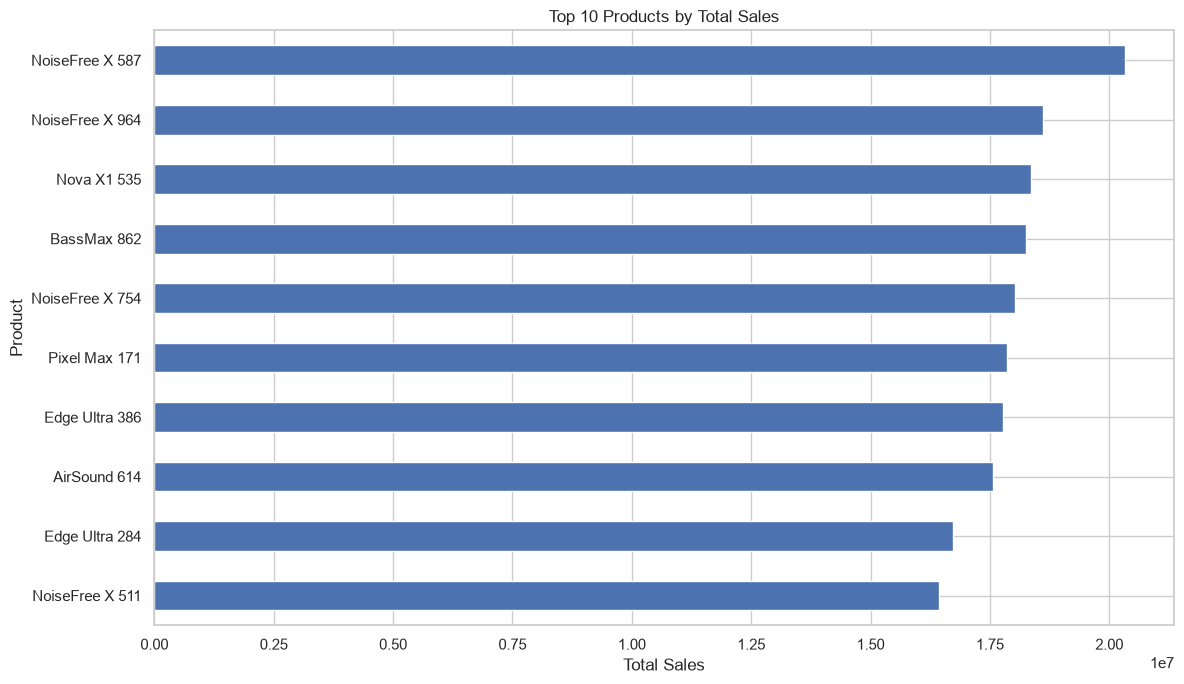

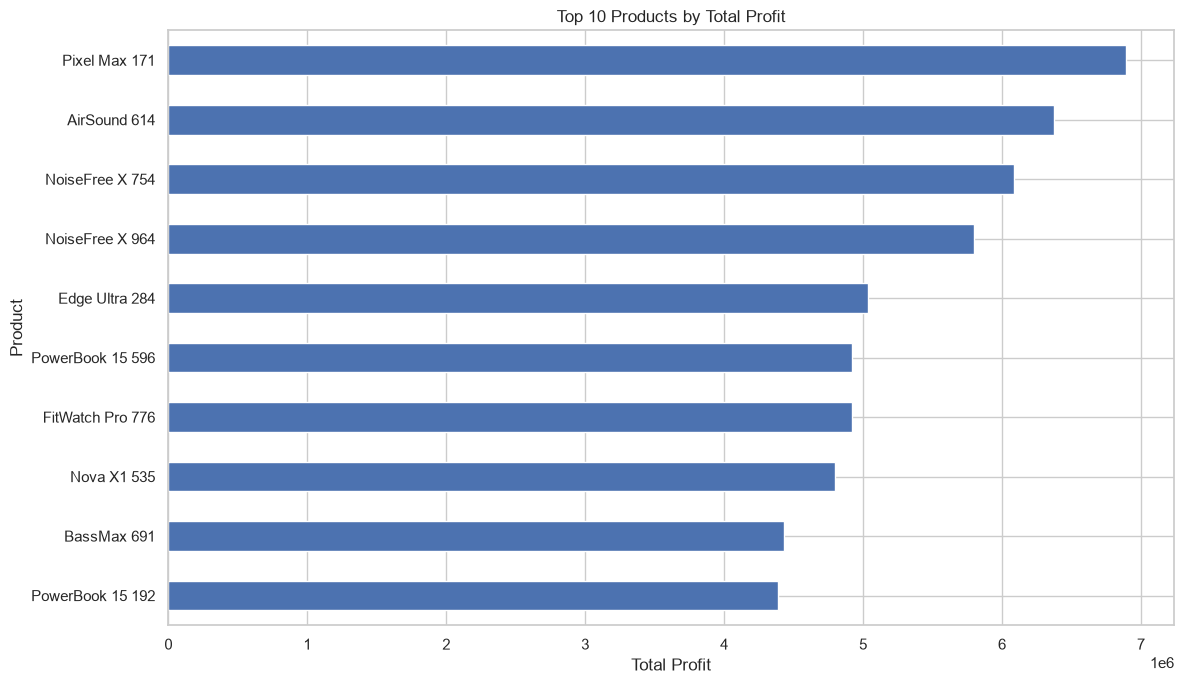

In [34]:
# ---------------------------------------------------
# TOP 10 PRODUCTS BY SALES
# ---------------------------------------------------

top_sales_products.sort_values(
    "total_sales"
).plot(
    x="product_name",
    y="total_sales",
    kind="barh",
    figsize=(12, 7),
    legend=False
)

plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()


# ---------------------------------------------------
# TOP 10 PRODUCTS BY PROFIT
# ---------------------------------------------------

top_profit_products.sort_values(
    "total_profit"
).plot(
    x="product_name",
    y="total_profit",
    kind="barh",
    figsize=(12, 7),
    legend=False
)

plt.title("Top 10 Products by Total Profit")
plt.xlabel("Total Profit")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

,discount_percentage,total_sales,total_profit,total_quantity,profit_margin_%
0,0,2.448499e+08,80644328.79,17572,32.94
1,5,1.980472e+08,57172362.74,14381,28.87
2,10,1.782126e+08,43323467.24,12377,24.31
3,15,9.641441e+07,18316986.79,7511,19.00
4,20,6.428377e+07,9261243.25,5360,14.41
5,25,3.486799e+07,3381971.98,3117,9.70
6,30,5.579367e+06,-479066.12,243,-8.59
7,35,1.756451e+06,-290232.04,114,-16.52
8,40,1.278721e+05,-16420.28,60,-12.84


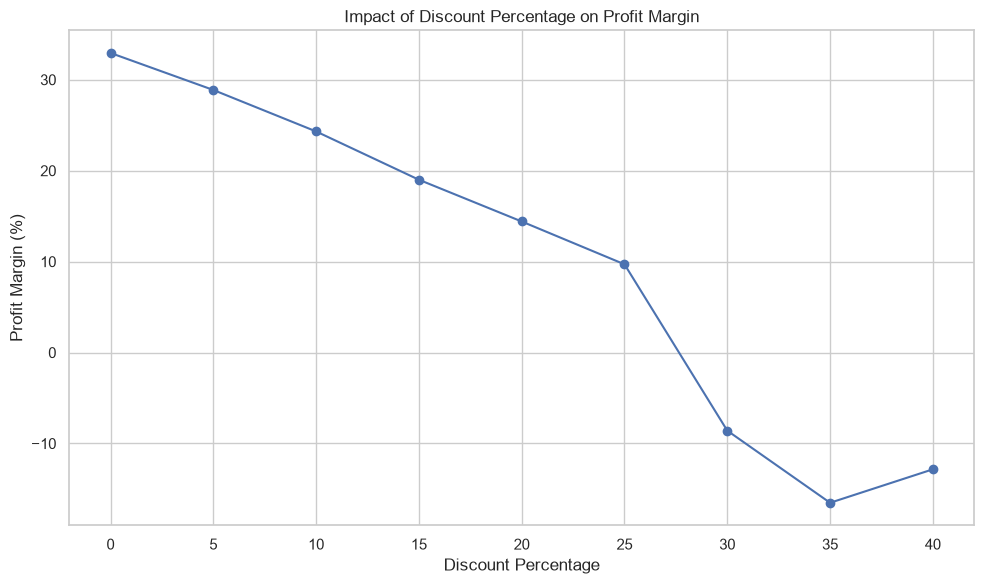

In [35]:
discount_analysis = (
    df.groupby("discount_percentage")
    .agg(
        total_sales=("sales_amount", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum")
    )
    .reset_index()
)

discount_analysis["profit_margin_%"] = (
    discount_analysis["total_profit"]
    / discount_analysis["total_sales"]
    * 100
).round(2)

display(discount_analysis)


# VISUALIZATION

plt.figure(figsize=(10, 6))

plt.plot(
    discount_analysis["discount_percentage"],
    discount_analysis["profit_margin_%"],
    marker="o"
)

plt.title("Impact of Discount Percentage on Profit Margin")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit Margin (%)")

plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
# ---------------------------------------------------
# TIME SERIES ANALYSIS
# ---------------------------------------------------

df["order_date"] = pd.to_datetime(df["order_date"])

df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.strftime("%b")
df["year_month"] = df["order_date"].dt.to_period("M").astype(str)


monthly_analysis = (
    df.groupby("year_month")
    .agg(
        total_sales=("sales_amount", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum")
    )
    .reset_index()
)

monthly_analysis["profit_margin_%"] = (
    monthly_analysis["total_profit"]
    / monthly_analysis["total_sales"]
    * 100
).round(2)


display(monthly_analysis.head())

,year_month,total_sales,total_profit,total_quantity,profit_margin_%
0,2024-01,35066586.65,9587821.98,2463,27.34
1,2024-02,27878150.07,7543529.23,2066,27.06
2,2024-03,37177337.89,10122199.87,2734,27.23
3,2024-04,35839578.11,9875972.81,2618,27.56
4,2024-05,35600254.75,9671022.75,2667,27.17


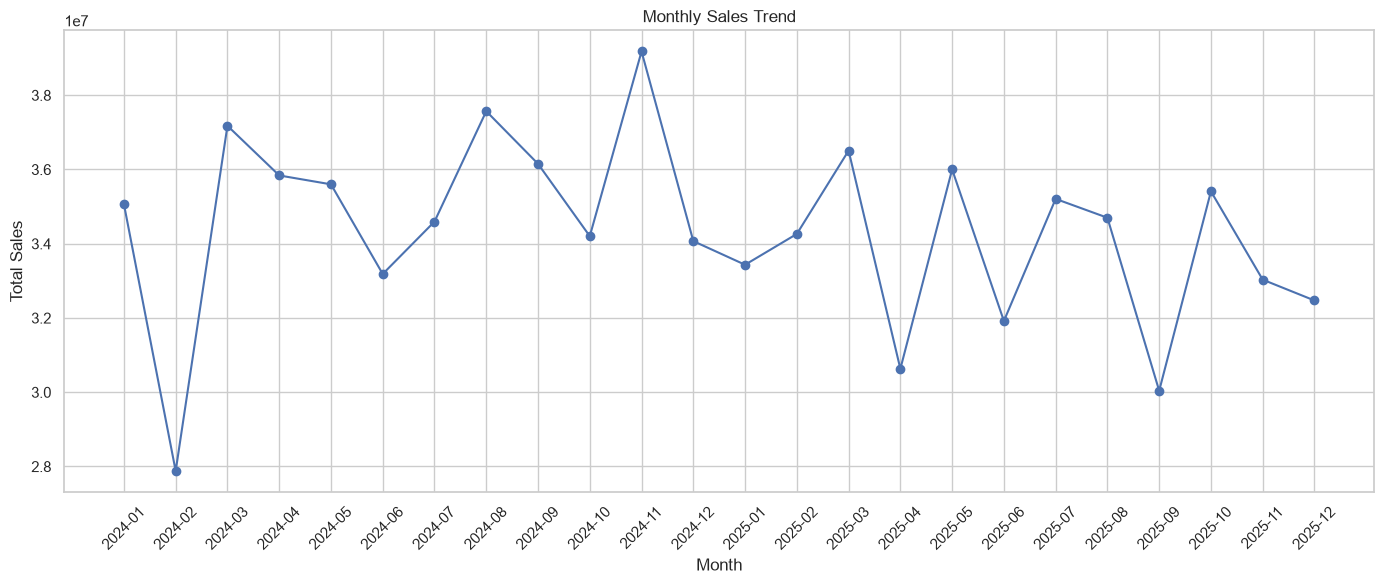

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["year_month"],
    monthly_analysis["total_sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

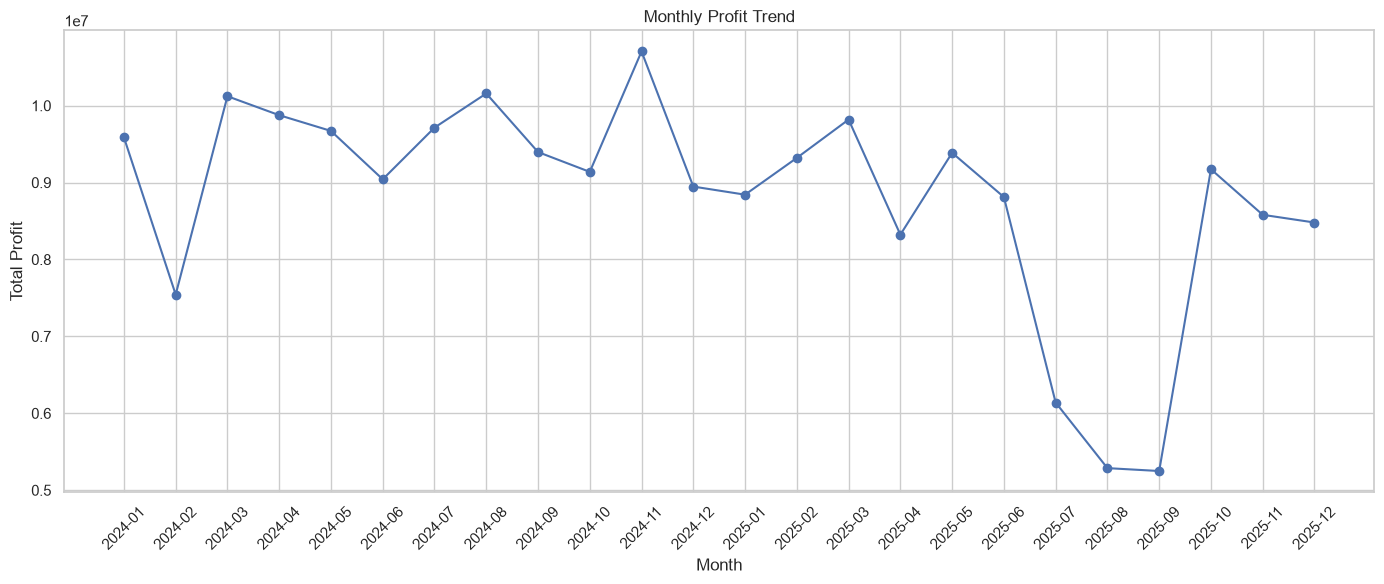

In [38]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_analysis["year_month"],
    monthly_analysis["total_profit"],
    marker="o"
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [39]:
# ---------------------------------------------------
# ELECTRONICS Q3 2025 PROFIT ANALYSIS
# ---------------------------------------------------

electronics_df = df[
    df["category"] == "Electronics"
].copy()


electronics_df["quarter"] = (
    electronics_df["order_date"]
    .dt.to_period("Q")
    .astype(str)
)


electronics_quarterly = (
    electronics_df.groupby("quarter")
    .agg(
        total_sales=("sales_amount", "sum"),
        total_cost=("total_cost", "sum"),
        total_profit=("profit", "sum"),
        avg_discount=("discount_percentage", "mean")
    )
    .reset_index()
)


electronics_quarterly["profit_margin_%"] = (
    electronics_quarterly["total_profit"]
    / electronics_quarterly["total_sales"]
    * 100
).round(2)


display(electronics_quarterly)

,quarter,total_sales,total_cost,total_profit,avg_discount,profit_margin_%
0,2024Q1,59671210.79,42840593.64,16830617.15,7.938034,28.21
1,2024Q2,63558048.71,45736485.95,17821562.76,8.201581,28.04
2,2024Q3,68482472.98,49557211.36,18925261.62,7.683897,27.64
3,2024Q4,65179413.08,47245370.33,17934042.75,8.165049,27.51
4,2025Q1,63658271.88,46381209.94,17277061.94,7.757937,27.14
5,2025Q2,56115304.66,40594586.22,15520718.44,7.240991,27.66
6,2025Q3,58396436.58,52669906.50,5726530.08,17.416830,9.81
7,2025Q4,61927331.38,45469321.77,16458009.61,8.409091,26.58


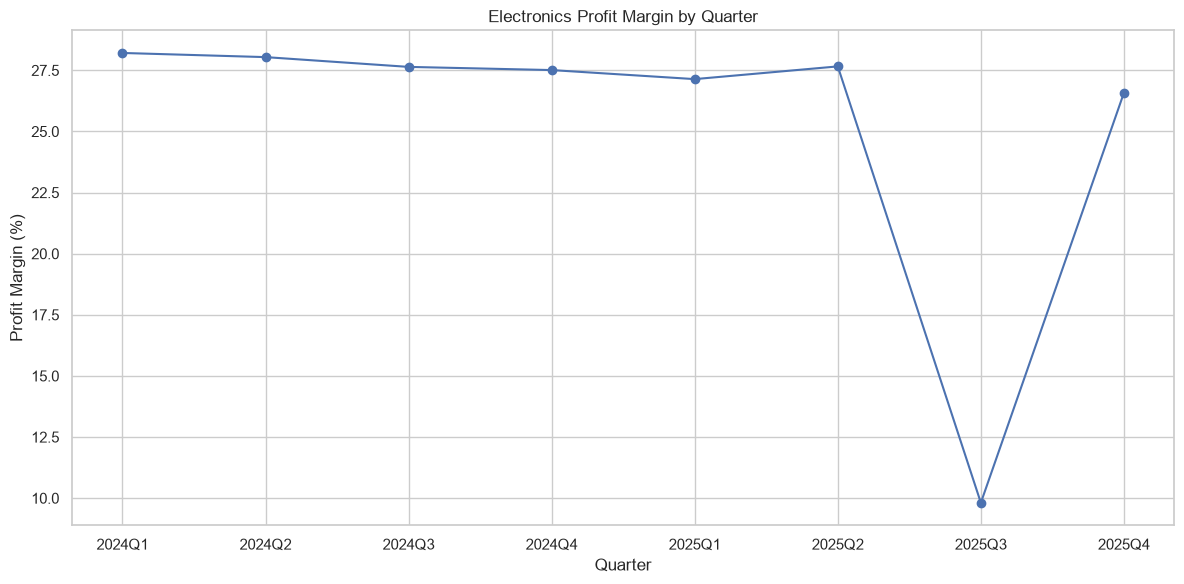

In [40]:
plt.figure(figsize=(12, 6))

plt.plot(
    electronics_quarterly["quarter"],
    electronics_quarterly["profit_margin_%"],
    marker="o"
)

plt.title("Electronics Profit Margin by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Profit Margin (%)")

plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
# ---------------------------------------------------
# CLOTHING DISCOUNT TRAP ANALYSIS
# ---------------------------------------------------

clothing_df = df[
    df["category"] == "Clothing"
].copy()


clothing_df["year_month"] = (
    clothing_df["order_date"]
    .dt.to_period("M")
    .astype(str)
)


clothing_monthly = (
    clothing_df.groupby("year_month")
    .agg(
        total_sales=("sales_amount", "sum"),
        total_profit=("profit", "sum"),
        avg_discount=("discount_percentage", "mean")
    )
    .reset_index()
)


clothing_monthly["profit_margin_%"] = (
    clothing_monthly["total_profit"]
    / clothing_monthly["total_sales"]
    * 100
).round(2)


# Focus on the months around the discount trap

clothing_discount_trap = clothing_monthly[
    clothing_monthly["year_month"].between(
        "2025-08",
        "2025-12"
    )
]

display(clothing_discount_trap)

,year_month,total_sales,total_profit,avg_discount,profit_margin_%
19,2025-08,1695141.94,427375.30,8.333333,25.21
20,2025-09,1636831.11,447498.82,7.865497,27.34
21,2025-10,1928891.36,512430.83,7.397959,26.57
22,2025-11,1267818.06,145443.25,22.292994,11.47
23,2025-12,1235052.82,133695.18,23.791946,10.83


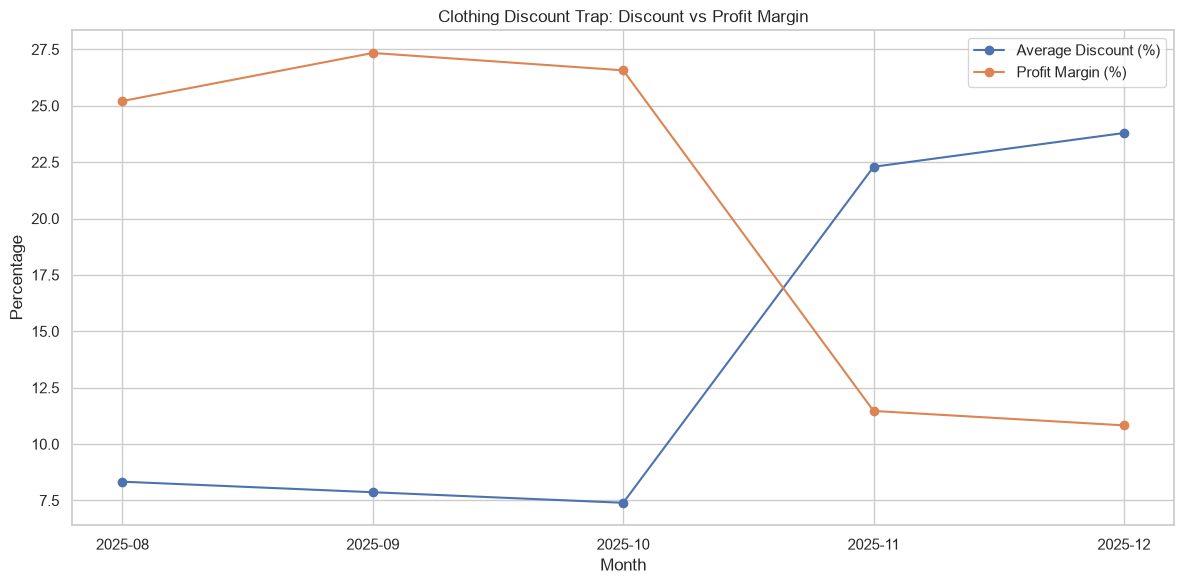

In [42]:
plt.figure(figsize=(12, 6))

plt.plot(
    clothing_discount_trap["year_month"],
    clothing_discount_trap["avg_discount"],
    marker="o",
    label="Average Discount (%)"
)

plt.plot(
    clothing_discount_trap["year_month"],
    clothing_discount_trap["profit_margin_%"],
    marker="o",
    label="Profit Margin (%)"
)

plt.title("Clothing Discount Trap: Discount vs Profit Margin")
plt.xlabel("Month")
plt.ylabel("Percentage")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [43]:
# ---------------------------------------------------
# CUSTOMER SEGMENT ANALYSIS
# ---------------------------------------------------

customer_analysis = (
    df.groupby("customer_segment")
    .agg(
        total_sales=("sales_amount", "sum"),
        total_profit=("profit", "sum"),
        total_quantity=("quantity", "sum"),
        unique_customers=("customer_id", "nunique")
    )
    .reset_index()
)

customer_analysis["profit_margin_%"] = (
    customer_analysis["total_profit"]
    / customer_analysis["total_sales"]
    * 100
).round(2)

display(customer_analysis)

,customer_segment,total_sales,total_profit,total_quantity,unique_customers,profit_margin_%
0,Budget,2.077360e+08,5.221871e+07,15258,487,25.14
1,Premium,1.641617e+08,4.250995e+07,11734,381,25.90
2,Regular,4.522418e+08,1.165860e+08,33743,1088,25.78


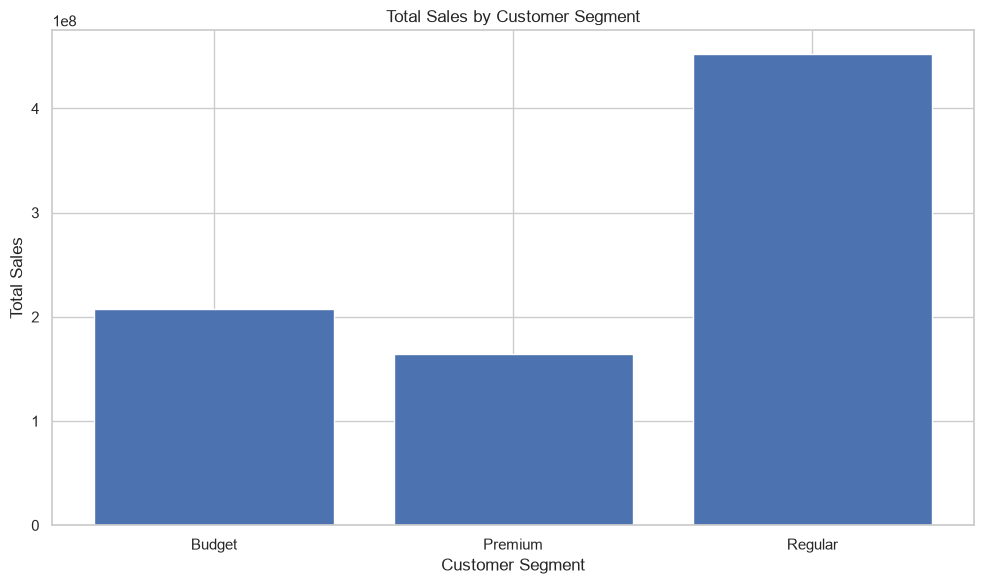

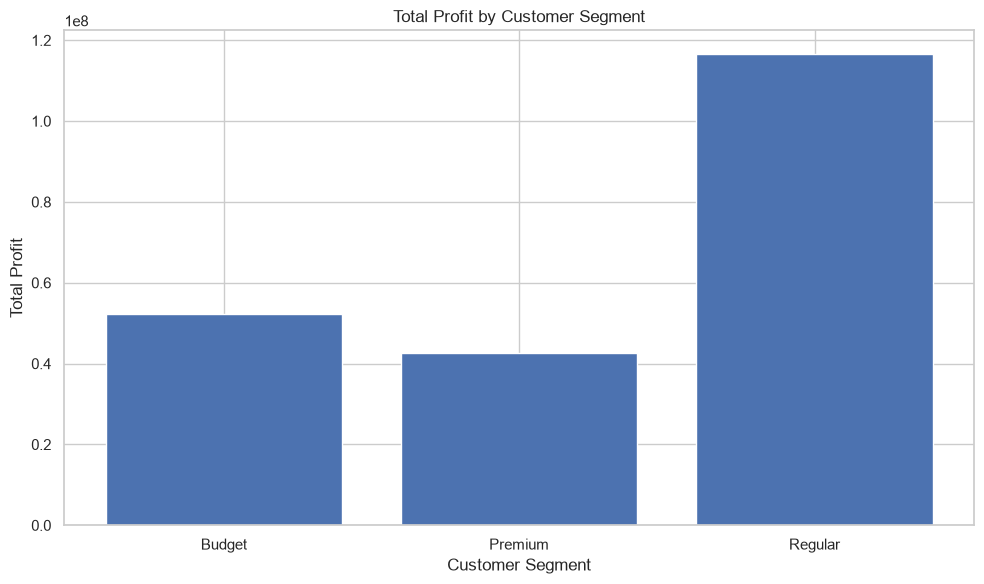

In [44]:
# ---------------------------------------------------
# CUSTOMER SEGMENT VISUALIZATIONS
# ---------------------------------------------------

plt.figure(figsize=(10, 6))

plt.bar(
    customer_analysis["customer_segment"],
    customer_analysis["total_sales"]
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))

plt.bar(
    customer_analysis["customer_segment"],
    customer_analysis["total_profit"]
)

plt.title("Total Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit")

plt.tight_layout()
plt.show()

In [45]:
# ---------------------------------------------------
# RETURNS ANALYSIS
# ---------------------------------------------------

returns_df = pd.read_csv(
    "../data/processed/returns_cleaned.csv"
)

products_df = pd.read_csv(
    "../data/processed/products_cleaned.csv"
)

order_items_df = pd.read_csv(
    "../data/processed/order_items_cleaned.csv"
)


# Calculate number of items sold per product

items_sold = (
    order_items_df
    .groupby("product_id")
    .size()
    .reset_index(name="items_sold")
)


# Calculate number of returns per product

product_returns = (
    returns_df
    .groupby("product_id")
    .size()
    .reset_index(name="returns")
)


# Merge datasets

return_analysis = items_sold.merge(
    product_returns,
    on="product_id",
    how="left"
)

return_analysis["returns"] = (
    return_analysis["returns"]
    .fillna(0)
)


return_analysis["return_rate_%"] = (
    return_analysis["returns"]
    / return_analysis["items_sold"]
    * 100
).round(2)


return_analysis = return_analysis.merge(
    products_df[
        [
            "product_id",
            "product_name",
            "category"
        ]
    ],
    on="product_id",
    how="left"
)


# Top return products

top_return_products = (
    return_analysis
    .sort_values(
        "return_rate_%",
        ascending=False
    )
    .head(15)
)

display(top_return_products)

,product_id,items_sold,returns,return_rate_%,product_name,category
94,P0095,72,21.0,29.17,Wall Clock 174,Home & Kitchen
184,P0185,79,23.0,29.11,Resistance Bands 181,Sports
21,P0022,79,22.0,27.85,FitWatch Pro 776,Electronics
50,P0051,77,21.0,27.27,Sports Backpack 190,Sports
170,P0171,82,22.0,26.83,Pulse X 415,Electronics
237,P0238,82,21.0,25.61,BassMax 862,Electronics
13,P0014,92,22.0,23.91,Winter Jacket 845,Clothing
5,P0006,90,21.0,23.33,Slim Fit Jeans 720,Clothing
40,P0041,69,16.0,23.19,Matte Lipstick 811,Beauty
179,P0180,76,17.0,22.37,Winter Jacket 714,Clothing


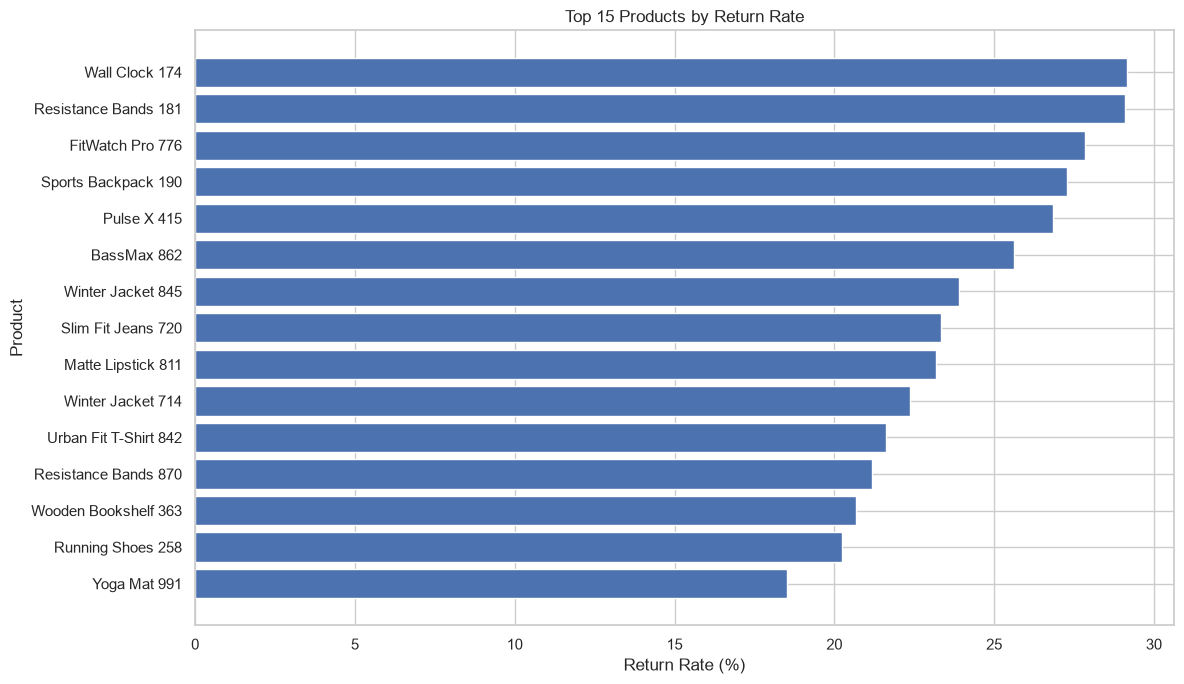

In [46]:
# ---------------------------------------------------
# TOP RETURN RATE PRODUCTS
# ---------------------------------------------------

top_return_products_sorted = (
    top_return_products
    .sort_values("return_rate_%")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_return_products_sorted["product_name"],
    top_return_products_sorted["return_rate_%"]
)

plt.title("Top 15 Products by Return Rate")
plt.xlabel("Return Rate (%)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

,category,items_sold,returns,return_rate_%
0,Beauty,3516,287.0,8.16
1,Clothing,4067,545.0,13.40
2,Electronics,3935,362.0,9.20
3,Home & Kitchen,4324,259.0,5.99
4,Sports,4276,268.0,6.27


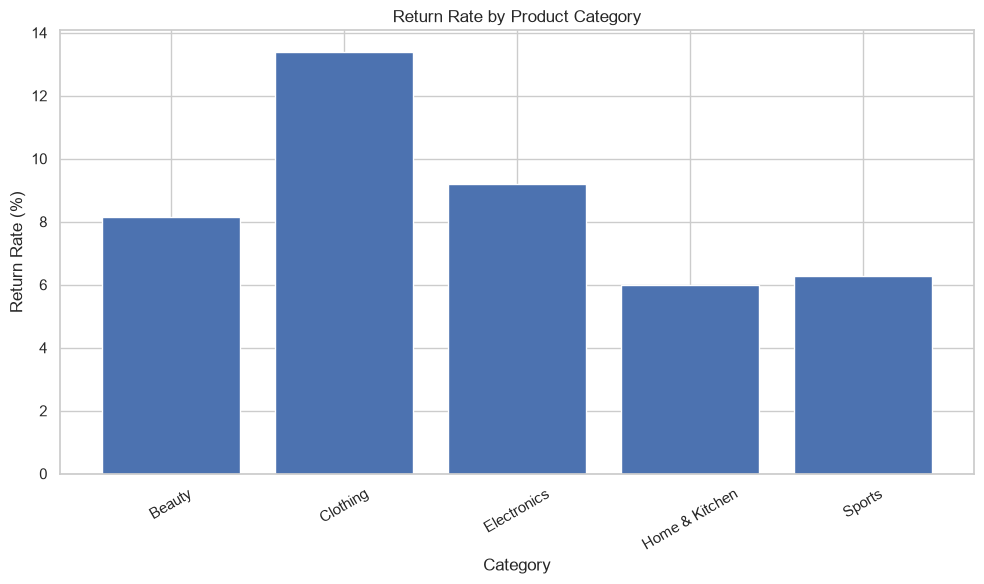

In [47]:
# ---------------------------------------------------
# RETURN RATE BY CATEGORY
# ---------------------------------------------------

category_returns = (
    return_analysis
    .groupby("category")
    .agg(
        items_sold=("items_sold", "sum"),
        returns=("returns", "sum")
    )
    .reset_index()
)

category_returns["return_rate_%"] = (
    category_returns["returns"]
    / category_returns["items_sold"]
    * 100
).round(2)


display(category_returns)


# Visualization

plt.figure(figsize=(10, 6))

plt.bar(
    category_returns["category"],
    category_returns["return_rate_%"]
)

plt.title("Return Rate by Product Category")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [48]:
# ---------------------------------------------------
# MARKETING CAMPAIGN ANALYSIS
# ---------------------------------------------------

campaigns_df = pd.read_csv(
    "../data/processed/marketing_campaigns_cleaned.csv"
)


campaign_analysis = (
    campaigns_df
    .groupby("channel")
    .agg(
        total_campaign_cost=("campaign_cost", "sum"),
        total_revenue=("revenue_generated", "sum"),
        average_roi=("roi_percentage", "mean"),
        campaign_count=("campaign_id", "count")
    )
    .reset_index()
)


display(campaign_analysis)

,channel,total_campaign_cost,total_revenue,average_roi,campaign_count
0,Affiliate Marketing,2488100.29,6056782.39,148.696667,9
1,Email,1252069.46,3163286.00,214.397500,4
2,Influencer Marketing,1920925.02,8097756.42,269.608750,8
3,Search Ads,2433348.61,5891320.10,214.413000,10
4,Social Media,2691441.51,4694953.88,92.532222,9


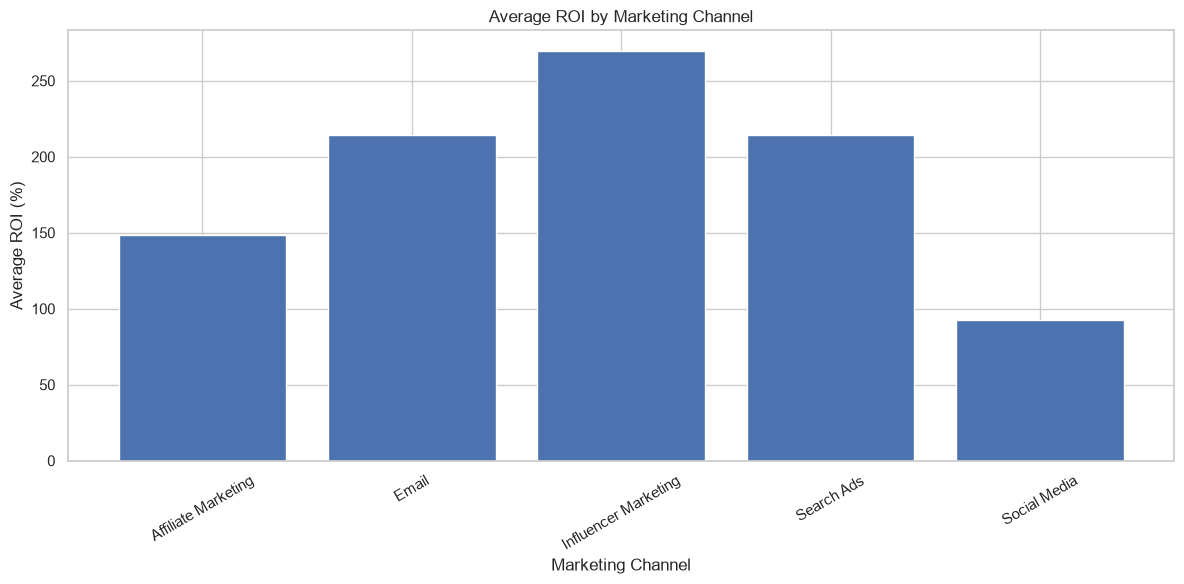

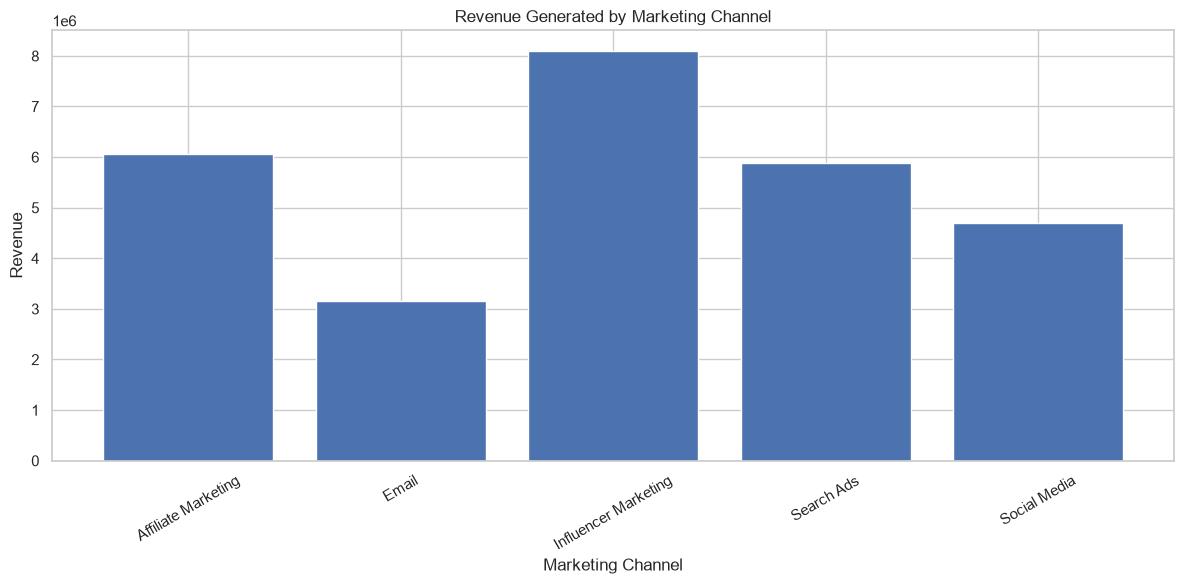

In [49]:
# ---------------------------------------------------
# MARKETING CHANNEL PERFORMANCE
# ---------------------------------------------------

plt.figure(figsize=(12, 6))

plt.bar(
    campaign_analysis["channel"],
    campaign_analysis["average_roi"]
)

plt.title("Average ROI by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Average ROI (%)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# Revenue generated by channel

plt.figure(figsize=(12, 6))

plt.bar(
    campaign_analysis["channel"],
    campaign_analysis["total_revenue"]
)

plt.title("Revenue Generated by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [50]:
# ---------------------------------------------------
# TOP AND BOTTOM MARKETING CAMPAIGNS
# ---------------------------------------------------

best_campaigns = (
    campaigns_df
    .sort_values(
        "roi_percentage",
        ascending=False
    )
    .head(10)
)

worst_campaigns = (
    campaigns_df
    .sort_values(
        "roi_percentage",
        ascending=True
    )
    .head(10)
)


print("TOP 10 CAMPAIGNS BY ROI")

display(
    best_campaigns[
        [
            "campaign_name",
            "channel",
            "campaign_cost",
            "revenue_generated",
            "roi_percentage",
            "performance_type"
        ]
    ]
)


print("BOTTOM 10 CAMPAIGNS BY ROI")

display(
    worst_campaigns[
        [
            "campaign_name",
            "channel",
            "campaign_cost",
            "revenue_generated",
            "roi_percentage",
            "performance_type"
        ]
    ]
)

TOP 10 CAMPAIGNS BY ROI


,campaign_name,channel,campaign_cost,revenue_generated,roi_percentage,performance_type
33,Festive Offer Search Ads 34,Search Ads,136178.18,942991.84,592.47,High
6,Weekend Deal Email 7,Email,246326.77,1686718.86,584.75,High
39,Festive Offer Influencer Marketing 40,Influencer Marketing,259700.21,1649836.82,535.29,High
38,Summer Sale Influencer Marketing 39,Influencer Marketing,378539.95,2245367.02,493.17,High
26,Flash Sale Search Ads 27,Search Ads,66851.08,388936.70,481.80,High
5,New Launch Influencer Marketing 6,Influencer Marketing,364771.70,2054184.95,463.14,High
8,Weekend Deal Affiliate Marketing 9,Affiliate Marketing,351330.17,1876830.09,434.21,High
34,Seasonal Promotion Affiliate Marketing 35,Affiliate Marketing,151858.71,628254.62,313.71,High
13,Mega Savings Search Ads 14,Search Ads,128829.68,522091.45,305.26,High
29,Weekend Deal Email 30,Email,151406.28,491336.90,224.52,Average


BOTTOM 10 CAMPAIGNS BY ROI


,campaign_name,channel,campaign_cost,revenue_generated,roi_percentage,performance_type
10,Premium Collection Email 11,Email,491536.50,321881.71,-34.52,Poor
23,Festive Offer Influencer Marketing 24,Influencer Marketing,182367.52,141445.18,-22.44,Poor
11,New Launch Social Media 12,Social Media,422168.62,329213.12,-22.02,Poor
28,Flash Sale Affiliate Marketing 29,Affiliate Marketing,302259.42,312339.54,3.33,Poor
37,Weekend Deal Affiliate Marketing 38,Affiliate Marketing,377447.37,398089.34,5.47,Poor
35,Festive Offer Social Media 36,Social Media,362760.55,394057.26,8.63,Poor
3,Weekend Deal Social Media 4,Social Media,369570.50,411042.65,11.22,Poor
2,New Launch Social Media 3,Social Media,403390.93,454134.44,12.58,Poor
19,Mega Savings Search Ads 20,Search Ads,450852.36,541838.43,20.18,Poor
16,Flash Sale Affiliate Marketing 17,Affiliate Marketing,82796.20,110372.38,33.31,Poor


In [51]:
# ---------------------------------------------------
# CORRELATION ANALYSIS
# ---------------------------------------------------

numerical_columns = [
    "quantity",
    "discount_percentage",
    "sales_amount",
    "total_cost",
    "profit"
]

correlation_matrix = df[numerical_columns].corr()

display(correlation_matrix)

,quantity,discount_percentage,sales_amount,total_cost,profit
quantity,1.000000,-0.003339,0.307919,0.305186,0.268931
discount_percentage,-0.003339,1.000000,-0.028839,0.033852,-0.181993
sales_amount,0.307919,-0.028839,1.000000,0.983681,0.892077
total_cost,0.305186,0.033852,0.983681,1.000000,0.796215
profit,0.268931,-0.181993,0.892077,0.796215,1.000000


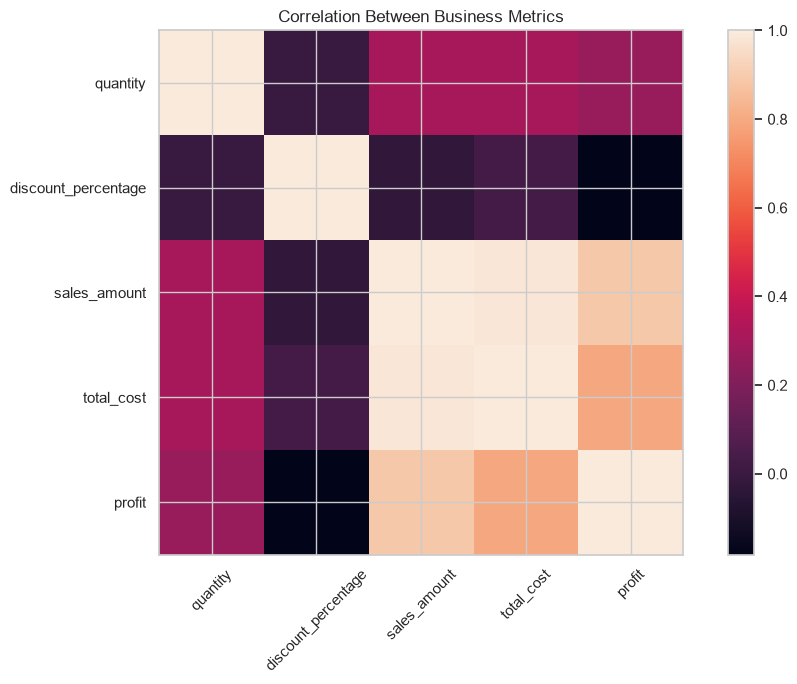

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.imshow(correlation_matrix)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Between Business Metrics")

plt.tight_layout()
plt.show()

In [53]:
# ---------------------------------------------------
# OVERALL BUSINESS KPIs
# ---------------------------------------------------

total_sales = df["sales_amount"].sum()

total_profit = df["profit"].sum()

total_quantity = df["quantity"].sum()

total_orders = df["order_id"].nunique()

total_customers = df["customer_id"].nunique()

overall_profit_margin = (
    total_profit / total_sales * 100
)

print("=" * 55)
print("OVERALL BUSINESS KPIs")
print("=" * 55)

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Overall Profit Margin: {overall_profit_margin:.2f}%")

OVERALL BUSINESS KPIs
Total Sales: 824,139,552.25
Total Profit: 211,314,642.35
Total Quantity Sold: 60,735
Total Orders: 7,996
Total Customers: 1,956
Overall Profit Margin: 25.64%


In [54]:
# ---------------------------------------------------
# KEY BUSINESS INSIGHTS
# ---------------------------------------------------

# Best category by sales
best_sales_category = (
    category_analysis["total_sales"]
    .idxmax()
)

best_sales_value = (
    category_analysis["total_sales"]
    .max()
)


# Best category by profit
best_profit_category = (
    category_analysis["total_profit"]
    .idxmax()
)

best_profit_value = (
    category_analysis["total_profit"]
    .max()
)


# Highest return category
highest_return_category = (
    category_returns
    .sort_values("return_rate_%", ascending=False)
    .iloc[0]
)


# Best marketing channel
best_marketing_channel = (
    campaign_analysis
    .sort_values("average_roi", ascending=False)
    .iloc[0]
)


# Best customer segment
best_customer_segment = (
    customer_analysis
    .sort_values("total_sales", ascending=False)
    .iloc[0]
)


print("=" * 65)
print("KEY BUSINESS INSIGHTS")
print("=" * 65)

print(
    f"\n1. Highest Sales Category: "
    f"{best_sales_category} "
    f"({best_sales_value:,.2f})"
)

print(
    f"\n2. Highest Profit Category: "
    f"{best_profit_category} "
    f"({best_profit_value:,.2f})"
)

print(
    f"\n3. Highest Return Rate Category: "
    f"{highest_return_category['category']} "
    f"({highest_return_category['return_rate_%']:.2f}%)"
)

print(
    f"\n4. Best Marketing Channel by Average ROI: "
    f"{best_marketing_channel['channel']} "
    f"({best_marketing_channel['average_roi']:.2f}%)"
)

print(
    f"\n5. Highest Sales Customer Segment: "
    f"{best_customer_segment['customer_segment']} "
    f"({best_customer_segment['total_sales']:,.2f})"
)

KEY BUSINESS INSIGHTS

1. Highest Sales Category: Electronics (496,988,490.06)

2. Highest Profit Category: Electronics (126,493,804.35)

3. Highest Return Rate Category: Clothing (13.40%)

4. Best Marketing Channel by Average ROI: Influencer Marketing (269.61%)

5. Highest Sales Customer Segment: Regular (452,241,834.46)


# EDA Summary

## Dataset Overview

The InsightRAG dataset contains transactional, customer, product,
returns, and marketing campaign data.

The dataset consists of:

- 2,000 customers
- 250 products
- 10,000 orders
- 20,118 order items
- 1,721 returns
- 40 marketing campaigns

---

## Key Areas Analyzed

### Sales and Profit Analysis

Sales and profit were analyzed across product categories,
individual products, and time periods.

Monthly trends were examined to identify changes in business
performance over time.

---

### Electronics Profitability Scenario

The analysis identified a significant decline in Electronics
profit margins during Q3 2025.

Despite relatively strong sales, profitability dropped significantly,
demonstrating that revenue alone may not accurately represent
business performance.

---

### Clothing Discount Trap

The Clothing category experienced significantly higher discounts
during November and December 2025.

Although sales continued during this period, profit margins
declined significantly, demonstrating the negative impact of
excessive discounting on profitability.

---

### Customer Analysis

Customer segments were analyzed based on total sales,
profit contribution, quantity purchased, and number of customers.

This helps identify which customer groups contribute the most
to overall business performance.

---

### Returns Analysis

Return rates were calculated for individual products and
product categories.

Several products demonstrated unusually high return rates,
which could indicate potential product quality, customer
expectation, or operational issues.

---

### Marketing Analysis

Marketing campaigns were evaluated using:

- Campaign Cost
- Revenue Generated
- ROI Percentage
- Marketing Channel
- Performance Type

The analysis identified the best and worst performing
marketing channels and campaigns.

---

## Conclusion

The exploratory data analysis successfully identified
important business trends, profitability issues, discount
risks, return patterns, customer behavior, and marketing
performance.

These insights will serve as the analytical foundation for
the InsightRAG system.

The next phase will focus on transforming these analytical
datasets and business insights into a Retrieval-Augmented
Generation (RAG) system capable of answering business
questions using the underlying data.